In [ ]:
# Preparo las librerías que voy a necesitar. Incluyo Sklearn y stats model para explorar los modelos desde ambas.

import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import numpy as np
import kagglehub
import os
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder as ohe, LabelEncoder as le
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split as tts, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from collections import defaultdict

seed = 333

In [ ]:
# Descargo la base de datos desde Kaggle.

path = kagglehub.dataset_download("yasserh/titanic-dataset")
print(path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
/kaggle/input/titanic-dataset


In [ ]:
# Abro el dataset.

df = pd.read_csv(os.path.join(path,"/kaggle/input/titanic-dataset/Titanic-Dataset.csv"))
df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
# Hago un análisis preliminar del tamaño del dataset, los nombres de las variables y el tipo de dato que contienen.

print(f"N Filas y columnas: \n{df.shape}\n\nTipos de variable: \n{df.dtypes}\n\nLista de variables:\n{df.columns}")

N Filas y columnas: 
(891, 12)

Tipos de variable: 
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Lista de variables:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [ ]:
# Examino si hay valores perdidos.

df.isnull().sum().sort_values(ascending=False)

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


In [ ]:
# Calculo variables FamilySize, IsAlone, CabinYesNo y Title.
df1 = df.copy()
df1['FamilySize'] = df1['Parch'] + df1['SibSp'] + 1
df1['IsAlone'] = (df1['FamilySize'] == 1).astype(int)
df1['CabinYesNo'] = df1['Cabin'].notnull().astype(int)
df1['Title'] = df1['Name'].str.extract(r',\s*(.+?)\.')
df1

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,CabinYesNo,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0,1,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1,0,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0,1,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1,0,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1,1,0,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1,1,1,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,4,0,0,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1,1,1,Mr


In [ ]:
# Reviso los valores de Name y recodifico en cinco categorías (Mr, Miss, Mrs, Master, Others).

print(f"Antes de mapear {df1['Title'].value_counts()}\n\nMissings: {df1['Title'].isnull().sum()}\n")

mapping = {'Mlle': 'Miss',
                 'Mme': 'Mrs',
                 'Dr':'Others',
                 'Rev':'Others',
                 'Major':'Others',
                 'Col':'Others',
                 'Capt':'Others',
                 'Don':'Others',
                 'Sir':'Others',
                 'Jonkheer':'Others',
                 'Lady':'Others',
                 'Ms':'Others',
                 'the Countess': 'Others'}

df1['Title'] = df1['Title'].map(mapping).fillna(df1['Title'])

print(f"Después de mapear {df1['Title'].value_counts()}\n\nMissings: {df1['Title'].isnull().sum()}")

Antes de mapear Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

Missings: 0

Después de mapear Title
Mr        517
Miss      184
Mrs       126
Master     40
Others     24
Name: count, dtype: int64

Missings: 0


In [ ]:
# Vuelvo a revisar el dataset con las nuevas variables para comprobar que se han incluido correctamente en el dataset.

print(f"N Filas y columnas: \n{df1.shape}\n\nTipos de variable: \n{df1.dtypes}\n\nLista de variables:\n{df1.columns}")

N Filas y columnas: 
(891, 16)

Tipos de variable: 
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
FamilySize       int64
IsAlone          int64
CabinYesNo       int64
Title           object
dtype: object

Lista de variables:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'FamilySize', 'IsAlone',
       'CabinYesNo', 'Title'],
      dtype='object')


In [ ]:
# Hago split en train y test.

x = df1.drop(columns='Survived')
y = df1['Survived']

x_train, x_test, y_train, y_test = tts(x, y, test_size=0.2, stratify=y, random_state=seed)

In [ ]:
# Examino el rango de valores de las variables.

print(f"Variables numéricas: \n \n{x_train.describe()}")
print()
print(f"Variables categóricas/de cadena: \n\n{x_train['Sex'].value_counts()},\n\n{x_train['Cabin'].value_counts()},\n\n{x_train['Embarked'].value_counts()},\n\n{x_train['Title'].value_counts()}")

Variables numéricas: 
 
       PassengerId      Pclass         Age       SibSp       Parch  \
count   712.000000  712.000000  575.000000  712.000000  712.000000   
mean    442.865169    2.307584   29.232313    0.540730    0.379213   
std     258.890207    0.841637   14.490591    1.123098    0.807500   
min       1.000000    1.000000    0.750000    0.000000    0.000000   
25%     220.750000    2.000000   20.000000    0.000000    0.000000   
50%     444.500000    3.000000   28.000000    0.000000    0.000000   
75%     667.500000    3.000000   38.000000    1.000000    0.000000   
max     891.000000    3.000000   80.000000    8.000000    6.000000   

             Fare  FamilySize     IsAlone  CabinYesNo  
count  712.000000  712.000000  712.000000  712.000000  
mean    32.179570    1.919944    0.595506    0.227528  
std     48.769104    1.637482    0.491139    0.419531  
min      0.000000    1.000000    0.000000    0.000000  
25%      7.895800    1.000000    0.000000    0.000000  
50%     1

array([[<Axes: title={'center': 'PassengerId'}>,
        <Axes: title={'center': 'Pclass'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'SibSp'}>,
        <Axes: title={'center': 'Parch'}>,
        <Axes: title={'center': 'Fare'}>],
       [<Axes: title={'center': 'FamilySize'}>,
        <Axes: title={'center': 'IsAlone'}>,
        <Axes: title={'center': 'CabinYesNo'}>]], dtype=object)

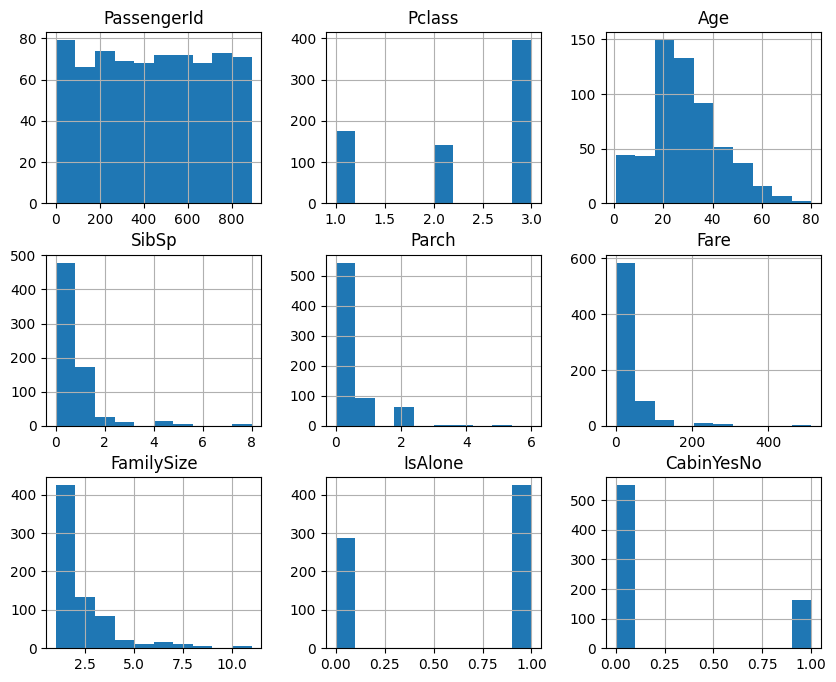

In [ ]:
# Examino las distribuciones de los valores de las variables.

x_train.hist(figsize=(10,8))

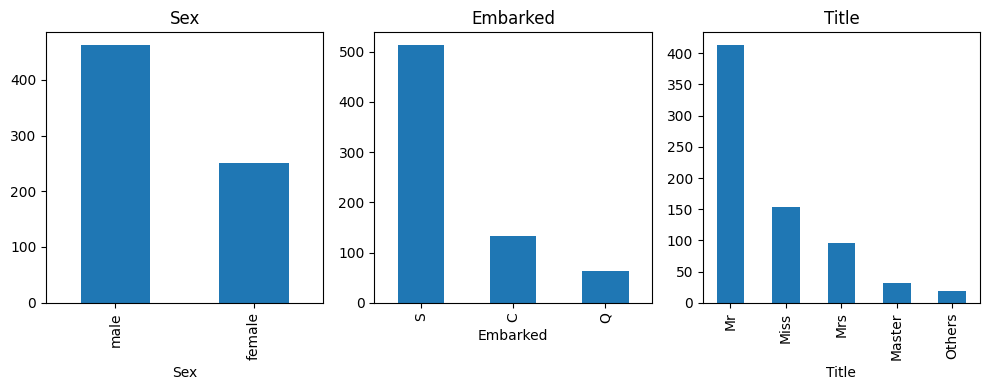

In [ ]:
fig,axes = plt.subplots(1, 3, figsize=(10,4))

x_train['Sex'].value_counts().plot(kind='bar', ax = axes[0], title = 'Sex')
x_train['Embarked'].value_counts().plot(kind='bar', ax = axes[1], title = 'Embarked')
x_train['Title'].value_counts().plot(kind='bar', ax = axes[2], title = 'Title')

plt.tight_layout()
plt.show()

In [ ]:
# Imputo los missings de Embarked para prepararlo para la recodificación.

moda = x_train['Embarked'].mode()[0]
x_train['Embarked'] = x_train['Embarked'].fillna(moda)
x_test['Embarked'] = x_test['Embarked'].fillna(moda)

In [ ]:
# Uso LabelEncoder y OneHotEncoder para transformar Sex,  PClass, Embarked y Title.

# Sex

le = le()
x_train['Sex'] = le.fit_transform(x_train['Sex'])
x_test['Sex'] = le.transform(x_test['Sex'])

# Pclass

ohe1 = ohe(drop = 'first', handle_unknown = 'ignore')
x_trainA = ohe1.fit_transform(x_train[['Pclass']]).toarray()
x_testA = ohe1.transform(x_test[['Pclass']]).toarray()

newcol1 = ohe1.get_feature_names_out(['Pclass'])

dfPclasstrain = pd.DataFrame(x_trainA, columns = newcol1, index=x_train.index)
dfPclasstest = pd.DataFrame(x_testA, columns = newcol1, index=x_test.index)

x_train = pd.concat([x_train,dfPclasstrain], axis = 1)
x_test = pd.concat([x_test,dfPclasstest], axis = 1)

# Embarked

ohe2 = ohe(drop = 'first', handle_unknown = 'ignore')
x_trainB = ohe2.fit_transform(x_train[['Embarked']]).toarray()
x_testB = ohe2.transform(x_test[['Embarked']]).toarray()

newcol2 = ohe2.get_feature_names_out(['Embarked'])

dfEmbarkedtrain = pd.DataFrame(x_trainB, columns = newcol2, index=x_train.index)
dfEmbarkedtest = pd.DataFrame(x_testB, columns = newcol2, index=x_test.index)

x_train = pd.concat([x_train,dfEmbarkedtrain], axis = 1)
x_test = pd.concat([x_test,dfEmbarkedtest], axis = 1)

# Title

ohe3 = ohe(drop = 'first', handle_unknown = 'ignore')
x_trainC = ohe3.fit_transform(x_train[['Title']]).toarray()
x_testC = ohe3.transform(x_test[['Title']]).toarray()

newcol3 = ohe3.get_feature_names_out(['Title'])

dfTitletrain = pd.DataFrame(x_trainC, columns = newcol3, index=x_train.index)
dfTitletest = pd.DataFrame(x_testC, columns = newcol3, index=x_test.index)

x_train = pd.concat([x_train,dfTitletrain], axis = 1)
x_test = pd.concat([x_test,dfTitletest], axis = 1)

x_train

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,CabinYesNo,Title,Pclass_2,Pclass_3,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Others
423,424,3,"Danbom, Mrs. Ernst Gilbert (Anna Sigrid Maria ...",0,28.0,1,1,347080,14.4000,NaN,S,3,0,0,Mrs,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
467,468,1,"Smart, Mr. John Montgomery",1,56.0,0,0,113792,26.5500,NaN,S,1,1,0,Mr,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
440,441,2,"Hart, Mrs. Benjamin (Esther Ada Bloomfield)",0,45.0,1,1,F.C.C. 13529,26.2500,NaN,S,3,0,0,Mrs,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
446,447,2,"Mellinger, Miss. Madeleine Violet",0,13.0,0,1,250644,19.5000,NaN,S,2,0,0,Miss,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
658,659,2,"Eitemiller, Mr. George Floyd",1,23.0,0,0,29751,13.0000,NaN,S,1,1,0,Mr,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,67,2,"Nye, Mrs. (Elizabeth Ramell)",0,29.0,0,0,C.A. 29395,10.5000,F33,S,1,1,1,Mrs,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
704,705,3,"Hansen, Mr. Henrik Juul",1,26.0,1,0,350025,7.8542,NaN,S,2,0,0,Mr,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
735,736,3,"Williams, Mr. Leslie",1,28.5,0,0,54636,16.1000,NaN,S,1,1,0,Mr,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
519,520,3,"Pavlovic, Mr. Stefo",1,32.0,0,0,349242,7.8958,NaN,S,1,1,0,Mr,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [ ]:
# Examino asimetrías.

x_train[['Fare', 'Age', 'SibSp', 'Parch', 'FamilySize']].skew()

,0
Fare,4.653112
Age,0.427160
SibSp,3.679481
Parch,2.806604
FamilySize,2.750167


In [ ]:
# Uso PowerTransformer para la asimetría de Fare.

pt = PowerTransformer()
x_train['Fare'] = pt.fit_transform(x_train[['Fare']])
x_test['Fare'] = pt.transform(x_test[['Fare']])

In [ ]:
# Imputación de valores nulos de Age estandarizando primero (y temporalmente) las variables.

neighbors = ['Age', 'Fare', 'Sex', 'FamilySize', 'CabinYesNo',
             'Pclass_2', 'Pclass_3', 'Embarked_Q', 'Embarked_S',
             'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Others']

# Estandarizar

scaler = StandardScaler()
x_trains = scaler.fit_transform(x_train[neighbors])
x_tests = scaler.transform(x_test[neighbors])

# Imputar

imputer = KNNImputer(n_neighbors=5)
x_trainI = imputer.fit_transform(x_trains)
x_testI = imputer.transform(x_tests)

# Generar dataframe con nombres de columna

x_trainT = pd.DataFrame(x_trainI, columns = neighbors, index = x_train.index)
x_testT = pd.DataFrame(x_testI, columns = neighbors, index = x_test.index)

# Revertir estandarización temporal

age_index = neighbors.index('Age')

x_trainAge = scaler.inverse_transform(x_trainT[neighbors])[:, age_index]
x_testAge = scaler.inverse_transform(x_testT[neighbors])[:, age_index]

# Sustituir valores perdidos de Age por los imputados

x_train['Age'] = x_trainAge
x_test['Age'] = x_testAge

In [ ]:
x_train
#x_test
#x_train.isnull().sum().sort_values(ascending=False)
#x_test.isnull().sum().sort_values(ascending=False)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,CabinYesNo,Title,Pclass_2,Pclass_3,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Others
423,424,3,"Danbom, Mrs. Ernst Gilbert (Anna Sigrid Maria ...",0,28.0,1,1,347080,-0.202901,NaN,S,3,0,0,Mrs,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
467,468,1,"Smart, Mr. John Montgomery",1,56.0,0,0,113792,0.405220,NaN,S,1,1,0,Mr,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
440,441,2,"Hart, Mrs. Benjamin (Esther Ada Bloomfield)",0,45.0,1,1,F.C.C. 13529,0.394102,NaN,S,3,0,0,Mrs,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
446,447,2,"Mellinger, Miss. Madeleine Violet",0,13.0,0,1,250644,0.100693,NaN,S,2,0,0,Miss,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
658,659,2,"Eitemiller, Mr. George Floyd",1,23.0,0,0,29751,-0.306038,NaN,S,1,1,0,Mr,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,67,2,"Nye, Mrs. (Elizabeth Ramell)",0,29.0,0,0,C.A. 29395,-0.522100,F33,S,1,1,1,Mrs,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
704,705,3,"Hansen, Mr. Henrik Juul",1,26.0,1,0,350025,-0.816072,NaN,S,2,0,0,Mr,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
735,736,3,"Williams, Mr. Leslie",1,28.5,0,0,54636,-0.090742,NaN,S,1,1,0,Mr,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
519,520,3,"Pavlovic, Mr. Stefo",1,32.0,0,0,349242,-0.810732,NaN,S,1,1,0,Mr,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [ ]:
# Preparo los datasets para el modelado.

erase_col = ['PassengerId', 'Pclass', 'Name', 'Ticket', 'Cabin', 'Embarked', 'Title', 'Sex', 'SibSp', 'Parch']
x_train_clean = x_train.drop(columns=erase_col)
x_test_clean = x_test.drop(columns=erase_col)

#x_train_clean.dtypes
#x_test_clean.dtypes

In [ ]:
# Checkeo el vif en train para ver si descarto variables (decido descartar Sex, SibSp y Parch en la celda previa).

x = sm.add_constant(x_train_clean, has_constant = 'add')
y = y_train.astype(float).copy()

for feature, col in enumerate(x.columns):
    vifs = vif(x.values,feature)
    print(f"{col}: {vifs:.2f}")

const: 63.43
Age: 1.86
Fare: 2.73
FamilySize: 2.47
IsAlone: 2.42
CabinYesNo: 2.63
Pclass_2: 3.47
Pclass_3: 6.00
Embarked_Q: 1.56
Embarked_S: 1.55
Title_Miss: 5.25
Title_Mr: 8.12
Title_Mrs: 4.50
Title_Others: 1.94


In [ ]:
# Desarrollo del modelo de regresión.

model = sm.Logit(y, x)
results = model.fit(method="lbfgs",maxiter=1000,disp=True)

print(f"{results.summary()}\n\nSurvival %:\n\n{results.predict(x)}")

                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  712
Model:                          Logit   Df Residuals:                      698
Method:                           MLE   Df Model:                           13
Date:                Tue, 08 Sep 2026   Pseudo R-squ.:                  0.4097
Time:                        12:29:26   Log-Likelihood:                -279.82
converged:                       True   LL-Null:                       -473.99
Covariance Type:            nonrobust   LLR p-value:                 6.446e-75
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            4.4387      0.909      4.884      0.000       2.657       6.220
Age             -0.0239      0.011     -2.174      0.030      -0.045      -0.002
Fare             0.4976      0.214      2.32

In [ ]:
# Elaboro las predicciones.

